<a href="https://colab.research.google.com/github/PrasannaGiri17/AI2/blob/main/AI_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_path = "/content/drive/MyDrive/FruitinAmazon.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully extracted '/content/drive/MyDrive/FruitinAmazon.zip' to '/content/'.


['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


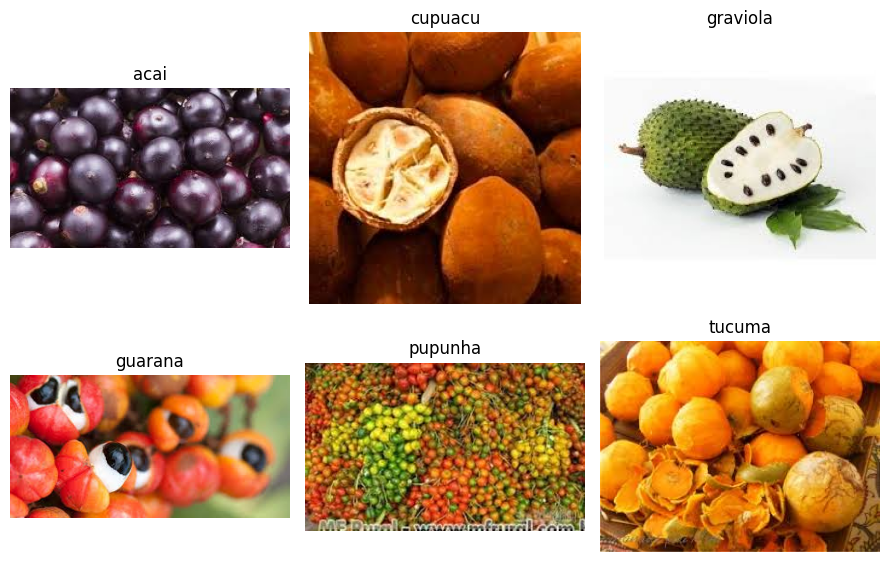

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_data_path = "/content/FruitinAmazon/train"
test_data_path = "/content/FruitinAmazon/test"

class_names = sorted([d for d in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, d))])

print(class_names)

selected_images_paths = []
selected_class_names = []

for class_name in class_names:
    class_dir = "/content/FruitinAmazon/train/" + class_name

    image_files = [f for f in os.listdir(class_dir)]

    if image_files:
        random_image_name = random.choice(image_files)
        selected_images_paths.append(os.path.join(class_dir, random_image_name))
        selected_class_names.append(class_name)
    else:
        print(f"Warning: No image files found in class directory: {class_dir}")

num_images = len(selected_images_paths)
num_rows = 2
num_cols = (num_images + num_rows - 1) // num_rows
plt.figure(figsize=(num_cols * 3, num_rows * 3))

for i, img_path in enumerate(selected_images_paths):
    try:
        img = Image.open(img_path)
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img)
        plt.title(selected_class_names[i])
        plt.axis("off")
    except Exception as e:
        print(f"Error loading or displaying image {img_path}: {e}")

plt.tight_layout()
plt.show()


### What did you observe?

- I found that each fruit has multiple images in its respective folder. And all the images of the fruits are from different angles, lighting conditions, orientations etc.

In [5]:
corrupted_images = []

for class_name in os.listdir(train_data_path):
    class_dir = os.path.join(train_data_path, class_name)

    if os.path.isdir(class_dir):
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)

            if os.path.isfile(image_path):
                try:
                    img = Image.open(image_path)
                    img.verify()
                except (IOError, SyntaxError) as e:
                    print(f"Removed corrupted image: {image_path}")
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                except Exception as e:
                    print(f"An unexpected error occurred with {image_path}: {e}")
                    corrupted_images.append(image_path)

if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [6]:
img_height = 128
img_width = 128
batch_size = 32

validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset="training",
  seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset="validation",
  seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [7]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_data_path,
  labels = 'inferred',
  label_mode = 'int',
  image_size = (img_height, img_width),
  interpolation = 'nearest',
  batch_size = batch_size,
  shuffle = False,
  seed = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

num_classes = len(class_names)

model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_filepath = 'best_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(train_ds,validation_data=val_ds,epochs=250, batch_size=16, callbacks=[model_checkpoint_callback, early_stopping_callback])

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    print("\nSample Predictions:")
    print("Predicted labels:", [class_names[p] for p in predicted_labels[:5]])
    print("Actual labels: ", [class_names[l] for l in labels.numpy()[:5]])

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 978ms/step - accuracy: 0.1806 - loss: 2.1301 - val_accuracy: 0.8333 - val_loss: 1.4122
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - accuracy: 0.0972 - loss: 1.7708 - val_accuracy: 0.7222 - val_loss: 1.4410
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.3333 - loss: 1.5893 - val_accuracy: 0.3889 - val_loss: 1.5187
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.4028 - loss: 1.4330 - val_accuracy: 0.7222 - val_loss: 1.2507
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.7222 - loss: 1.1177 - val_accuracy: 0.6667 - val_loss: 1.2035
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 681ms/step - accuracy: 0.6528 - loss: 0.9234 - val_accuracy: 0.7222 - val_loss: 0.9414
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.8889 - loss: 0.6549 - val_accuracy: 0.6111 - val_loss: 1.0076
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.9167 - loss: 0.4589 - val_accuracy: 0.8333 - val_loss: 0.4

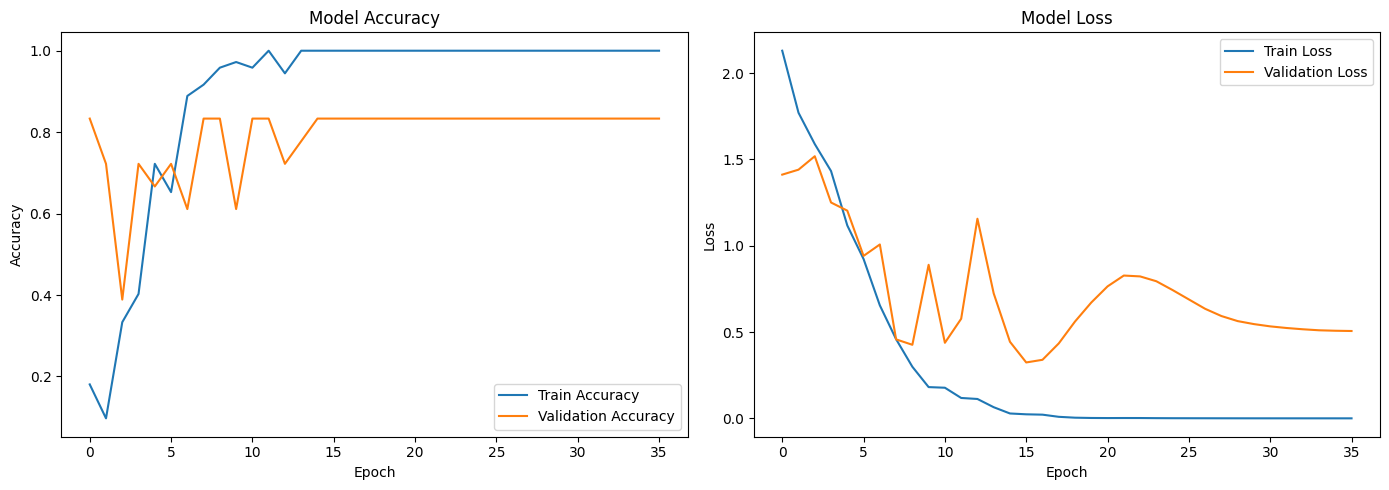

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8333 - loss: 0.3241
Validation Loss: 0.3241
Validation Accuracy: 0.8333


In [11]:
model_save_path = 'fruit_classifier_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to fruit_classifier_model.h5


In [12]:
loaded_model = keras.models.load_model('fruit_classifier_model.h5')
print("Model loaded successfully!")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8333 - loss: 0.3241

Loaded Model Validation Loss: 0.3241
Loaded Model Validation Accuracy: 0.8333


In [13]:
from sklearn.metrics import classification_report

y_true = []
y_pred_probs = []

for images, labels in test_ds:
  preds = loaded_model.predict(images, verbose=0)
  y_pred_probs.extend(preds)
  y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)
print('Predicted labels:', [class_names[i] for i in y_pred[:5]])
print('Actual labels :', [class_names[i] for i in y_true[:5]])

print(classification_report(y_true, y_pred, target_names=class_names))

Predicted labels: ['guarana', 'guarana', 'acai', 'acai', 'acai']
Actual labels : ['acai', 'acai', 'acai', 'acai', 'acai']
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      0.60      0.75         5
     guarana       0.42      1.00      0.59         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.88      0.73      0.74        30
weighted avg       0.88      0.73      0.74        30



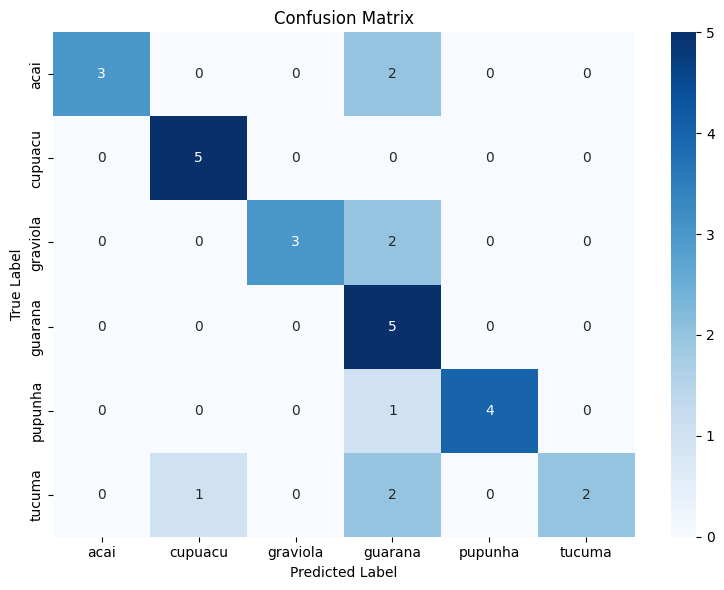

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2639 - loss: 8.5546 - val_accuracy: 0.1667 - val_loss: 1.7685
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.2778 - loss: 16.0313 - val_accuracy: 0.2222 - val_loss: 2.0728
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3889 - loss: 10.3655 - val_accuracy: 0.2222 - val_loss: 2.7243
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5278 - loss: 8.7052 - val_accuracy: 0.2222 - val_loss: 2.9665
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5278 - loss: 7.2712 - val_accuracy: 0.3333 - val_loss: 3.3001
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5694 - loss: 5.2162 - val_accuracy: 0.3333 - val_loss: 3.4265
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5694 - loss: 4.0316 - val_accuracy: 0.3333 - val_loss: 3.833

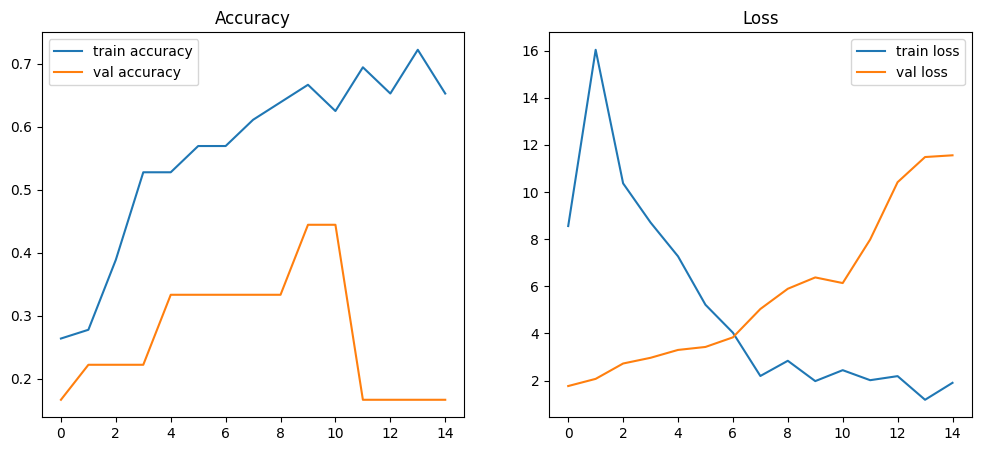

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 📁 Dataset path
train_dir = "/content/FruitinAmazon/train"

# 📏 Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# 🔹 Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# 🔹 Rescaling
rescale = layers.Rescaling(1./255)

# 📂 Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 📌 Class info
class_names = train_ds.class_names
num_classes = len(class_names)

# 🔹 Apply preprocessing
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ⚡ Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🧠 Improved CNN Model
model = models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),

    # Data Augmentation
    data_augmentation,

    # 🔹 Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# ⚙️ Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 📊 Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# 📈 Plot Accuracy & Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")

plt.show()

In [16]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

In [17]:
train_dir = "/content/FruitinAmazon/train"

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [18]:
rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

In [19]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
for layer in base_model.layers:
    layer.trainable = False

In [21]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [22]:
for layer in base_model.layers:
    layer.trainable = False

In [23]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(num_classes, activation='softmax')(x)

In [24]:
model = models.Model(inputs=base_model.input, outputs=x)

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 27s/step - accuracy: 0.1806 - loss: 1.8814 - val_accuracy: 0.1667 - val_loss: 1.8451
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 25s/step - accuracy: 0.4583 - loss: 1.5143 - val_accuracy: 0.3333 - val_loss: 1.7837
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 24s/step - accuracy: 0.5972 - loss: 1.3508 - val_accuracy: 0.3889 - val_loss: 1.6509
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 20s/step - accuracy: 0.6528 - loss: 1.2056 - val_accuracy: 0.3889 - val_loss: 1.5540
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 23s/step - accuracy: 0.7361 - loss: 1.0131 - val_accuracy: 0.3889 - val_loss: 1.4533
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 20s/step - accuracy: 0.7917 - loss: 0.9392 - val_accuracy: 0.3889 - val_loss: 1.4730
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 21s/step - accuracy: 0.7639 - loss: 0.8297 - val_accuracy: 0.4444 - val_loss: 1.4175
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 25s/step - accuracy: 0.7917 - loss: 0.7269 - val_accuracy: 0.5556 - val_loss: 1.3775


In [27]:
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Show some predictions
for i in range(10):
    print(f"Actual: {class_names[y_true[i]]} | Predicted: {class_names[y_pred[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Actual: guarana | Predicted: graviola
Actual: pupunha | Predicted: guarana
Actual: guarana | Predicted: pupunha
Actual: pupunha | Predicted: cupuacu
Actual: guarana | Predicted: tucuma
Actual: cupuacu | Predicted: pupunha
Actual: pupunha | Predicted: graviola
Actual: tucuma | Predicted: guarana
Actual: guarana | Predicted: cupuacu
Actual: guarana | Predicted: guarana


In [28]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.25      0.33      0.29         3
     guarana       0.20      0.20      0.20         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.50      0.33      0.40         3

    accuracy                           0.17        18
   macro avg       0.16      0.14      0.15        18
weighted avg       0.18      0.17      0.17        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
